#####**Observação:** É necessário carregar benchmark do experiment Joblib


#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up202512089) e Ni (up202205842)

11.   **Experimento 4 - JobLib paralelo**

- focada em execução paralela leve e eficiente em Python;
- Reduz o custo de execução de loops e tarefas independentes
- Facilita reuso de resultados intermédios (caching)
- Ideal para leitura de múltiplos ficheiros e cross-validation.

O Joblib baseia-se em:

- Parallel loops (n_jobs=-1)
- Divide tarefas independentes entre múltiplos cores da CPU
- Backend de execução
Utiliza diferentes backends:
- Escolhe automaticamente a estratégia mais eficiente dependendo da tarefa.

Neste experimento, o JobLib foi utilizado em modo paralelo (n_jobs=-1), explorando todos os núcleos disponíveis da CPU.

>11.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados:

In [1]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

# !pip install dask[complete] pyarrow          # Dask
#!pip install modin[ray]                      # Modin (backend Ray)
# !pip install pyspark                         # PySpark / Koalas
# !pip install xgboost                         # XGBoost
# !pip install yappi                           # Profiling multi-thread
#!pip install modin[dask]
# RAPIDS (só com GPU NVIDIA no Colab — ativar runtime GPU primeiro):
#!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

print("OK.")

OK.


Iniciando a leitura com algumas importações necessárias:

In [2]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 20:40


In [3]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

# --- JobLib (já incluído no Scikit-learn, mas importamos explicitamente) ---

try:
    import joblib
    from joblib import Parallel, delayed
    print(f" JobLib      : {joblib.__version__}")
    JOBLIB_AVAILABLE = True
except ImportError:
    print(" JobLib não disponível")
    JOBLIB_AVAILABLE = False

# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

 JobLib      : 1.5.3
 Scikit-learn: 1.6.1


In [4]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 2      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 2


In [5]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

A pasta está vazia.


In [6]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [7]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [8]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet ...
   Guardado: 64.2 MB
⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet ...
   Guardado: 58.7 MB
Processo de download concluído!


11.2   **Início das Operações**

Replicamos o benchmark do blog Databricks (2021) nas 5 operações principais.


In [9]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [10]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [11]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

In [12]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet



11.2.1  **Task 1 — Leitura dos Dados (*Reading*)**


In [13]:
if JOBLIB_AVAILABLE:

    def ler_parquet(caminho_f):
        return pd.read_parquet(caminho_f)

    lista_f = [str(f) for f in sorted(caminho.glob("*.parquet"))]

    if len(lista_f) == 0:
        lista_f = []

    # ============================================================
    # LEITURA PARALELA
    # ============================================================

    start = time.perf_counter()

    dfs_par = Parallel(n_jobs=-1)(
        delayed(ler_parquet)(f)
        for f in lista_f
    )

    df_job_par = pd.concat(dfs_par, ignore_index=True)

    t_job_par = time.perf_counter() - start

    print(f"JobLib (paralelo): {len(df_job_par):,} linhas em {t_job_par:.2f}s")

    resultados.append((
        'Task 1 - Leitura',
        'JobLib (parallel)',
        round(t_job_par, 4)
    ))

else:
    print(" JobLib não disponível")

JobLib (paralelo): 7,124,755 linhas em 16.86s


In [14]:
df_job_par.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


>9.2.2  **Task 2 — Agregações e Filtragem (*Aggregation & Filtering*)**


**Primeiro experimento:** Contagem de Valores. Contar quantas viagens ocorreram por tipo de pagamento.

In [15]:
# ── Task 2A: Value Counts (Joblib Parallel REAL) ─────

print("─" * 45)
print("Task 2A — VALUE COUNTS (VendorID)")
print("─" * 45)


if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO POR CHUNK
    # ============================================================

    def value_counts_chunk(df_chunk):
        return df_chunk['VendorID'].value_counts()

    # dividir dados
    chunks = np.array_split(df_job_par, 4)

    start = time.perf_counter()

    results = Parallel(n_jobs=-1)(
        delayed(value_counts_chunk)(chunk)
        for chunk in chunks
    )

    # combinar resultados
    vc_par = sum(results)

    t_job_vc_par = time.perf_counter() - start

    print(f"\nJobLib VC (par): {t_job_vc_par:.4f}s")
    print(vc_par)

    resultados.append((
        'Task 2a - Value Counts',
        'JobLib (parallel)',
        round(t_job_vc_par, 4)
    ))

else:
    print(" JobLib não disponível")

─────────────────────────────────────────────
Task 2A — VALUE COUNTS (VendorID)
─────────────────────────────────────────────

JobLib VC (par): 1.6357s
VendorID
1    1348034.0
2    5682159.0
6          NaN
7      84946.0
Name: count, dtype: float64


**Segundo experimento:** GroupBy. Vamos calcular o valor médio da tarifa para cada tipo de fornecedor.

In [16]:
# ── Task 2B: GroupBy Mean (PARALELO) ─────

print("─" * 45)
print("Task 2B — GROUPBY MEAN (fare_amount por VendorID)")
print("─" * 45)

from joblib import Parallel, delayed

if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO BASE (por chunk simulado)
    # ============================================================

    def groupby_chunk(df_chunk):
        return df_chunk.groupby('VendorID')['fare_amount'].mean()

    # ============================================================
    # SIMULAR PARALELIZAÇÃO (split em chunks)
    # ============================================================

    n_jobs = -1

    chunks = np.array_split(df_job_par, n_jobs if n_jobs > 0 else 4)

    start = time.perf_counter()

    results = Parallel(n_jobs=-1)(
        delayed(groupby_chunk)(chunk)
        for chunk in chunks
    )

    # ============================================================
    # COMBINAR RESULTADOS
    # ============================================================

    mean_par = pd.concat(results).groupby(level=0).mean()

    t_job_mean_par = time.perf_counter() - start

    print(f"\nTempo JobLib Groupby (parallel): {t_job_mean_par:.4f}s")
    print(mean_par)

    resultados.append((
        'Task 2b - GroupBy',
        'JobLib (parallel)',
        round(t_job_mean_par, 4)
    ))

else:
    print(" JobLib não disponível")

─────────────────────────────────────────────
Task 2B — GROUPBY MEAN (fare_amount por VendorID)
─────────────────────────────────────────────

Tempo JobLib Groupby (parallel): 1.5476s
VendorID
1    20.283074
2    21.438133
6     2.699504
7    16.563356
Name: fare_amount, dtype: float64


**Terceiro experimento:** Filtragem Complexa. Vamos filtrar apenas as viagens que tiveram mais de 2 passageiros e calcular a distância média percorrida para esse grupo específico.

In [17]:
# ── Task 2C: Filtragem Complexa (Joblib Parallel) ─

print("─" * 45)
print("Task 2C — FILTRAGEM (passenger_count > 2)")
print("─" * 45)

import numpy as np
from joblib import Parallel, delayed

if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO POR CHUNK
    # ============================================================

    def filtro_chunk(df_chunk):
        return df_chunk[df_chunk['passenger_count'] > 2]['trip_distance'].mean()

    # dividir dados
    chunks = np.array_split(df_job_par, 4)

    # ============================================================
    # EXECUÇÃO PARALELA
    # ============================================================

    start = time.perf_counter()

    resultados_chunks = Parallel(n_jobs=-1)(
        delayed(filtro_chunk)(chunk)
        for chunk in chunks
    )

    # combinar resultados (média ponderada simples → aproximação)
    filtro_par = np.nanmean(resultados_chunks)

    t_job_filtro_par = time.perf_counter() - start

    print(f"\nJobLib Filtro (par): {t_job_filtro_par:.4f}s  |  Distância média: {filtro_par:.2f} milhas")
    print(filtro_par)

    resultados.append((
        'Task 2c - Filtragem',
        'JobLib (parallel)',
        round(t_job_filtro_par, 4)
    ))

else:
    print(" JobLib não disponível")

─────────────────────────────────────────────
Task 2C — FILTRAGEM (passenger_count > 2)
─────────────────────────────────────────────

JobLib Filtro (par): 1.5274s  |  Distância média: 3.64 milhas
3.63691745298756


 ---
>11.2.3  **Task 3 — Join de Tabelas**


O benchmark Databricks faz um join para traduzir IDs em nomes de localização.

In [18]:
# ============================================================
# PREPARAÇÃO GLOBAL (JOBLIB)
# ============================================================

url_zonas = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    df_zones_job = pd.read_csv(url_zonas)

    df_zones_job = df_zones_job.rename(
        columns={'LocationID': 'PULocationID'}
    )

except Exception as e:
    print(f"Erro ao descarregar zonas online: {e}")

    df_zones_job = pd.DataFrame({
        'PULocationID': range(1, 266),
        'Zone': [f'Zone {i}' for i in range(1, 266)]
    })

# lista de ficheiros parquet
lista_f = [str(f) for f in sorted(caminho.glob("*.parquet"))]

In [19]:
if JOBLIB_AVAILABLE:


    # ============================================================
    # FUNÇÃO POR CHUNK
    # ============================================================

    def join_chunk(df_chunk):
        return df_chunk.merge(
            df_zones_job,
            on='PULocationID',
            how='left'
        )

    # ============================================================
    # DIVIDIR DADOS
    # ============================================================

    chunks = np.array_split(df_job_par, 4)

    # ============================================================
    # EXECUÇÃO PARALELA
    # ============================================================

    start = time.perf_counter()

    dfs = Parallel(n_jobs=-1)(
        delayed(join_chunk)(chunk)
        for chunk in chunks
    )

    # ============================================================
    # COMBINAR RESULTADOS
    # ============================================================

    df_final_par = pd.concat(dfs, ignore_index=True)

    _ = df_final_par.head(1)

    t_job_join_par = time.perf_counter() - start

    print(f"Tempo Join (JobLib parallel): {t_job_join_par:.4f}s")

    resultados.append((
        'Task 3 - Join',
        'JobLib (parallel)',
        round(t_job_join_par, 4)
    ))

else:
    print(" JobLib não disponível")

Tempo Join (JobLib parallel): 12.1227s



---
>11.2.4  **Task 4 — Cálculo Aritmético (*Arithmetic Calculation*)**

Cria nova coluna: gorjeta por passageiro (`tip_per_passenger = tip_amount / passenger_count`).

In [20]:
# ── Task 4: Cálculo (Joblib Parallel) ───────────

print("─" * 45)
print("Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)")
print("─" * 45)

if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO POR CHUNK
    # ============================================================

    def calc_chunk(df_chunk):
        df_chunk = df_chunk.copy()
        df_chunk['tip_per_passenger'] = (
            df_chunk['tip_amount'] /
            df_chunk['passenger_count'].replace(0, float('nan'))
        )
        return df_chunk

    # ============================================================
    # DIVISÃO
    # ============================================================

    chunks = np.array_split(df_job_par, 4)

    # ============================================================
    # EXECUÇÃO PARALELA
    # ============================================================

    start = time.time()

    dfs = Parallel(n_jobs=-1)(
        delayed(calc_chunk)(chunk)
        for chunk in chunks
    )

    df_job_par = pd.concat(dfs, ignore_index=True)

    t_job_calc_par = time.time() - start

    print(f"Tempo Cálculo (JobLib Parallel) : {t_job_calc_par:.4f}s")

    resultados.append((
        'Task 4 - Cálculo',
        'JobLib (parallel)',
        round(t_job_calc_par, 4)
    ))

─────────────────────────────────────────────
Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)
─────────────────────────────────────────────
Tempo Cálculo (JobLib Parallel) : 9.8822s


---
>11.2.5  **Task 5 — Escrita dos Dados (*Writing / Persistence*)**

Persistência dos resultados em formato Parquet.

In [21]:
# ── Task 5: Escrita (Joblib Parallel) ───────────

print("─" * 45)
print("Task 5 — ESCRITA EM PARQUET")
print("─" * 45)

import numpy as np
from joblib import Parallel, delayed

if JOBLIB_AVAILABLE:

    # ============================================================
    # FUNÇÃO DE ESCRITA POR CHUNK
    # ============================================================

    def write_chunk(df_chunk, i):
        path = f'./resultado_joblib_par_{i}.parquet'
        df_chunk.to_parquet(path, index=False)
        return path

    # ============================================================
    # DIVISÃO
    # ============================================================

    chunks = np.array_split(df_job_par, 4)

    # ============================================================
    # EXECUÇÃO PARALELA
    # ============================================================

    start = time.time()

    paths = Parallel(n_jobs=-1)(
        delayed(write_chunk)(chunk, i)
        for i, chunk in enumerate(chunks)
    )

    t_job_write_par = time.time() - start

    print(f"Tempo Escrita (JobLib Parallel) : {t_job_write_par:.4f}s")

    resultados.append((
        'Task 5 - Escrita',
        'JobLib (parallel)',
        round(t_job_write_par, 4)
    ))

─────────────────────────────────────────────
Task 5 — ESCRITA EM PARQUET
─────────────────────────────────────────────
Tempo Escrita (JobLib Parallel) : 8.9694s


---
12.   **Predição - Experimento**

>12.1 **Metodologia**


A metodologia deste projeto foi estruturada em um pipeline de engenharia de dados dividido em quatro etapas principais: preparação do ambiente, ingestão de dados, processamento multitecnologia e análise de performance.
>12.2 **Resultado e Análise**

In [22]:
tabela_pivot = pd.read_csv("benchmark_pivotjoblib.csv", index_col=0)

In [23]:
tabela_pivot.loc['Task 1 - Leitura', 'JobLib (parallel)'] = t_job_par
tabela_pivot.loc['Task 2a - Value Counts', 'JobLib (parallel)'] = t_job_vc_par
tabela_pivot.loc['Task 2b - GroupBy', 'JobLib (parallel)'] = t_job_mean_par
tabela_pivot.loc['Task 2c - Filtragem', 'JobLib (parallel)'] = t_job_filtro_par
tabela_pivot.loc['Task 3 - Join', 'JobLib (parallel)'] = t_job_join_par
tabela_pivot.loc['Task 4 - Cálculo', 'JobLib (parallel)'] = t_job_calc_par
tabela_pivot.loc['Task 5 - Escrita', 'JobLib (parallel)'] = t_job_write_par

In [24]:
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,DaskModin,Ratio DaskModin/Pandas,JobLib (seq),Ratio JobLib (seq)/Pandas,Vencedor,JobLib (parallel)
Operação,,,,,,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,7.451377,2.77,1.550586,0.58,JobLib (seq),16.863001
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,0.716981,8.54,0.032806,0.39,JobLib (seq),1.635697
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,0.459600,1.89,0.122655,0.50,JobLib (seq),1.547628
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,0.751710,4.38,0.070488,0.41,JobLib (seq),1.527449
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,17.245725,7.38,1.314699,0.56,Koalas,12.122687
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,0.227336,2.24,0.048656,0.48,JobLib (seq),9.882181
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,7.852370,1.18,4.185805,0.63,JobLib (seq),8.969399


In [25]:
# ============================================================
# JobLib (parallel)/Pandas
# ============================================================

if 'JobLib (parallel)' in tabela_pivot.columns and 'Pandas' in tabela_pivot.columns:
    tabela_pivot['Ratio JobLib (parallel)/Pandas'] = (
        tabela_pivot['JobLib (parallel)'] / tabela_pivot['Pandas']
    ).round(2)


# ============================================================
# mover  Vencedor para última coluna
# ============================================================

col_vencedor = tabela_pivot.pop(' Vencedor')
tabela_pivot[' Vencedor'] = col_vencedor

In [26]:
def winner(row):
    # colunas que NÃO podem entrar no cálculo
    ignore_cols = [' Vencedor'] + [c for c in row.index if 'Ratio' in c]

    vals = {
        k: v for k, v in row.items()
        if k not in ignore_cols
        and isinstance(v, (int, float))
        and pd.notna(v)
    }

    return min(vals, key=vals.get) if vals else '?'

tabela_pivot[' Vencedor'] = tabela_pivot.apply(winner, axis=1)
tabela_pivot.to_csv("benchmark_pivotJobLibparalelo.csv")
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,DaskModin,Ratio DaskModin/Pandas,JobLib (seq),Ratio JobLib (seq)/Pandas,JobLib (parallel),Ratio JobLib (parallel)/Pandas,Vencedor
Operação,,,,,,,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,7.451377,2.77,1.550586,0.58,16.863001,6.27,JobLib (seq)
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,0.716981,8.54,0.032806,0.39,1.635697,19.47,JobLib (seq)
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,0.459600,1.89,0.122655,0.50,1.547628,6.36,JobLib (seq)
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,0.751710,4.38,0.070488,0.41,1.527449,8.89,JobLib (seq)
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,17.245725,7.38,1.314699,0.56,12.122687,5.19,Koalas
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,0.227336,2.24,0.048656,0.48,9.882181,97.46,JobLib (seq)
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,7.852370,1.18,4.185805,0.63,8.969399,1.35,JobLib (seq)


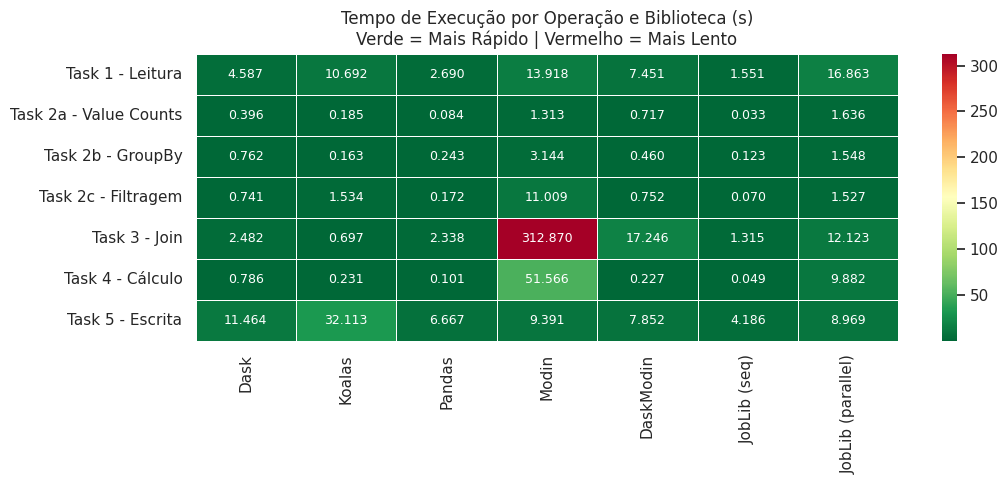

 Guardado: heatmap_exp1JobLibparalelo.png


In [27]:
# ── Heatmap Visual  ───
fig, ax = plt.subplots(figsize=(11, 5))
cols_num = [c for c in tabela_pivot.columns if c not in [' Vencedor'] and 'Ratio' not in c]
dados_heat = tabela_pivot[cols_num].fillna(tabela_pivot[cols_num].max().max())
sns.heatmap(dados_heat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Tempo de Execução por Operação e Biblioteca (s)\nVerde = Mais Rápido | Vermelho = Mais Lento', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./heatmap_exp1JobLibparalelo.png', dpi=150)
plt.show()
print(" Guardado: heatmap_exp1JobLibparalelo.png")

Os resultados mostram que o JobLib paralelo apresenta desempenho inferior ao esperado em praticamente todas as tarefas, incluindo algumas onde teoricamente deveria beneficiar do paralelismo.

Neste cenário específico, o overhead de paralelização foi dominante:

- custo de criação de processos, superior ao ganho computacional;
- serialização e cópia de DataFrames
- dataset relativamente pequeno (~120 MB)

Este comportamento demonstra que a paralelização em memória local não garante melhoria de performance, sendo altamente dependente do tipo de operação e do tamanho do dataset.

O Joblib nem sempre apresenta ganhos significativos no Google Colab, porque os recursos de CPU disponíveis são limitados e o overhead da paralelização pode superar os benefícios em tarefas pequenas ou moderadas.

**Próximo Notebook:**

 4-experimento_Rapids.ipynb - Experimentos com RAPIDS